In [30]:
import matplotlib.pyplot as plt

In [31]:
import os

import numpy as np
import pandas as pd

In [32]:
def parse_forecast_file(file_path):
    """
    Parse forecast file and extract date-price data
    """
    dates = []
    prices = []

    with open(file_path, "r") as file:
        lines = file.readlines()

        # Find the start of forecast data
        start_reading = False
        for line in lines:
            line = line.strip()

            if line == "Forecast Data:":
                start_reading = True
                continue

            if start_reading and line.startswith("----"):
                continue

            if start_reading and line.startswith("Overall Statistics:"):
                break

            if start_reading and ":" in line and line != "Forecast Data:":
                try:
                    date_str, price_str = line.split(": ")
                    dates.append(pd.to_datetime(date_str))
                    prices.append(float(price_str))
                except ValueError:
                    continue

    return dates, prices

In [33]:
# Define the forecast price folder path
forecast_folder = "forecast_price"

# Define crop names and their corresponding file names
crops = {
    "Cassava": "cassava_forecast.txt",
    "Corn": "corn_forecast.txt",
    "Green Bean": "green_bean_forecast.txt",
    "Soybean": "soybean_forecast.txt",
}

In [34]:
crop_data = {}

for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)

    if os.path.exists(file_path):
        dates, prices = parse_forecast_file(file_path)
        crop_data[crop_name] = {"dates": dates, "prices": prices}
        print(f"Loaded {crop_name} data: {len(prices)} price points")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nLoaded data for {len(crop_data)} crops")

crop_price_avg = {}

for crop_name, data in crop_data.items():
    dates = data["dates"]
    prices = data["prices"]

    if len(prices) > 0:
        avg_price = np.round(np.mean(prices), 2)
        crop_price_avg[crop_name] = avg_price
        print(f"{crop_name} average price: {avg_price:.2f}")
    else:
        print(f"No price data available for {crop_name}")


Loaded Cassava data: 12 price points
Loaded Corn data: 12 price points
Loaded Green Bean data: 12 price points
Loaded Soybean data: 12 price points

Loaded data for 4 crops
Cassava average price: 3.00
Corn average price: 11.22
Green Bean average price: 24.64
Soybean average price: 18.42


In [35]:
print(crop_price_avg["Cassava"])
print(crop_price_avg["Corn"])
print(crop_price_avg["Green Bean"])
print(crop_price_avg["Soybean"])

for crop_name, data in crop_data.items():
    new_data_lst = []

    # Access the 'prices' list from the data dictionary
    for price in data["prices"]:
        if price != 0:
            new_data_lst.append(price / float(crop_price_avg[crop_name]))

    # Update the prices with normalized values
    crop_data[crop_name]["prices"] = new_data_lst

print(crop_data["Cassava"])
print(crop_data["Corn"])
print(crop_data["Green Bean"])
print(crop_data["Soybean"])

3.0
11.22
24.64
18.42
{'dates': [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-06-01 00:00:00'), Timestamp('2024-07-01 00:00:00'), Timestamp('2024-08-01 00:00:00'), Timestamp('2024-09-01 00:00:00'), Timestamp('2024-10-01 00:00:00'), Timestamp('2024-11-01 00:00:00'), Timestamp('2024-12-01 00:00:00')], 'prices': [1.1666666666666667, 1.1033333333333333, 1.07, 1.0466666666666666, 1.0233333333333332, 1.0, 0.9766666666666667, 0.9566666666666667, 0.9366666666666666, 0.9166666666666666, 0.9, 0.8866666666666667]}
{'dates': [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-06-01 00:00:00'), Timestamp('2024-07-01 00:00:00'), Timestamp('2024-08-01 00:00:00'), Timestamp('2024-09-01 00:00:00'), Timestamp('2024-10-01 00:00:00'),

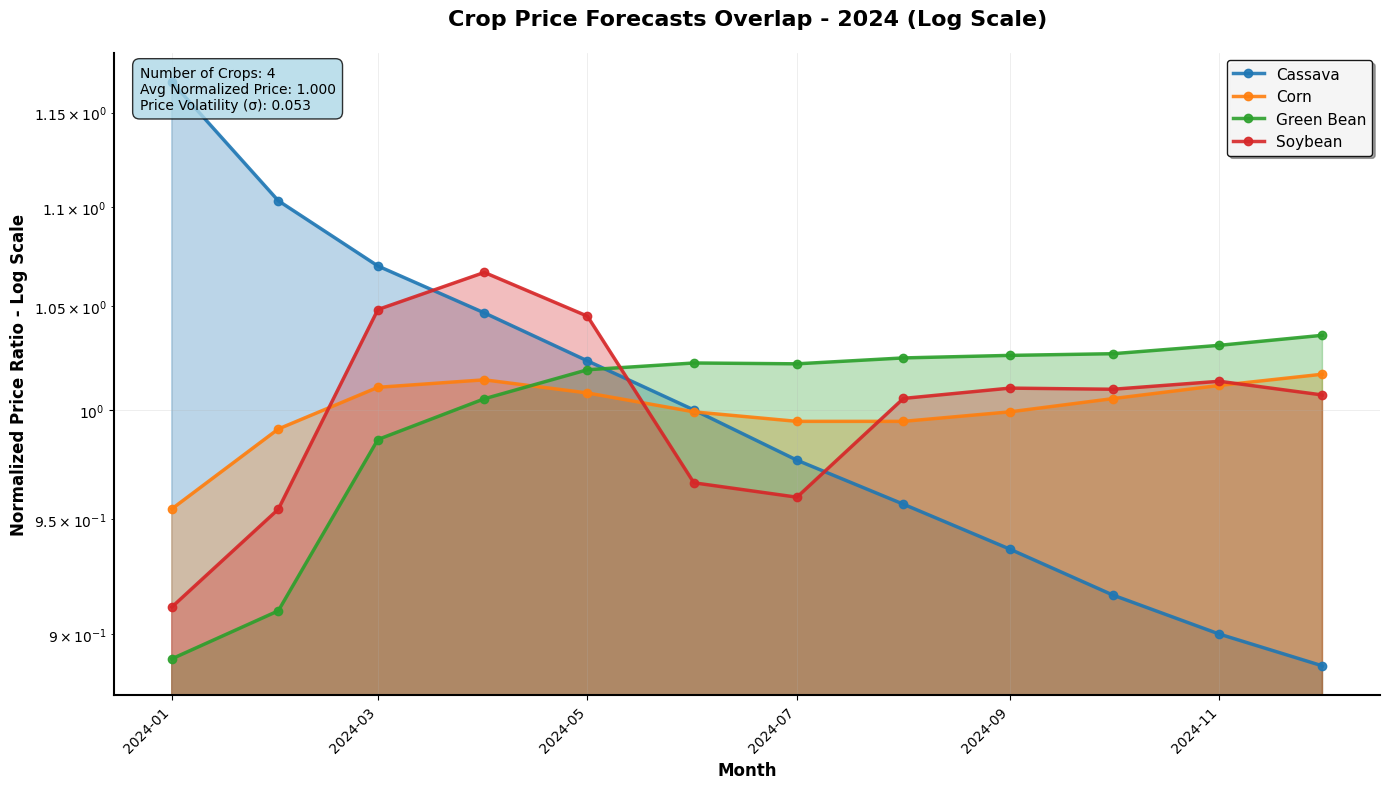

In [ ]:
# Create the overlapping price plot with enhanced styling
plt.figure(figsize=(14, 8))

# Define colors and styles similar to the reference plot
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # Blue, Orange, Green, Red
fill_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # Matching fill colors
line_styles = ["-", "-", "-", "-"]  # All solid lines for cleaner look

# Plot each crop's price data with area fill
for i, (crop_name, data) in enumerate(crop_data.items()):
    # Plot the line
    plt.plot(
        data["dates"],
        data["prices"],
        color=colors[i],
        linewidth=2.5,
        linestyle=line_styles[i],
        marker="o",
        markersize=6,
        label=f"{crop_name}",
        alpha=0.9,
    )

    # Add area fill under each line
    plt.fill_between(
        data["dates"],
        data["prices"],
        alpha=0.3,
        color=fill_colors[i],
    )

# Set logarithmic scale for y-axis
plt.yscale("log")

# Customize the plot with enhanced styling
plt.title(
    "Crop Price Forecasts Overlap - 2024 (Log Scale)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Month", fontsize=12, fontweight="bold")
plt.ylabel("Normalized Price Ratio - Log Scale", fontsize=12, fontweight="bold")

# Format the legend with better styling
plt.legend(
    loc="upper right",
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True,
    facecolor="white",
    edgecolor="black",
    framealpha=0.9,
)

# Enhanced grid formatting
plt.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)

# Format the axes with better rotation and spacing
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Add enhanced styling
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Add statistics text box
if crop_data:
    stats_text = f"Number of Crops: {len(crop_data)}\n"

    # Calculate some basic statistics
    all_prices = []
    for data in crop_data.values():
        all_prices.extend(data["prices"])

    if all_prices:
        avg_normalized = np.mean(all_prices)
        std_normalized = np.std(all_prices)
        stats_text += f"Avg Normalized Price: {avg_normalized:.3f}\n"
        stats_text += f"Price Volatility (σ): {std_normalized:.3f}"

    # Add text box in the upper left
    plt.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="lightblue",
            alpha=0.8,
            edgecolor="black",
        ),
    )

# Show the plot
plt.show()

In [37]:
# Display summary statistics for each crop
print("=" * 60)
print("CROP PRICE FORECAST SUMMARY STATISTICS - 2024")
print("=" * 60)
for crop_name, data in crop_data.items():
    prices = np.array(data["prices"])

    print(f"\n{crop_name}:")
    print(f"  Average Price: ${prices.mean():.2f}")
    print(f"  Minimum Price: ${prices.min():.2f}")
    print(f"  Maximum Price: ${prices.max():.2f}")
    print(f"  Price Range: ${prices.max() - prices.min():.2f}")
    print(f"  Standard Deviation: ${prices.std():.2f}")

    # Calculate price trend (comparing first and last months)
    if len(prices) >= 2:
        trend = ((prices[-1] - prices[0]) / prices[0]) * 100
        trend_direction = (
            "increasing" if trend > 0 else "decreasing" if trend < 0 else "stable"
        )
        print(f"  Overall Trend: {trend:+.1f}% ({trend_direction})")

print("\n" + "=" * 60)

CROP PRICE FORECAST SUMMARY STATISTICS - 2024

Cassava:
  Average Price: $1.00
  Minimum Price: $0.89
  Maximum Price: $1.17
  Price Range: $0.28
  Standard Deviation: $0.08
  Overall Trend: -24.0% (decreasing)

Corn:
  Average Price: $1.00
  Minimum Price: $0.95
  Maximum Price: $1.02
  Price Range: $0.06
  Standard Deviation: $0.02
  Overall Trend: +6.5% (increasing)

Green Bean:
  Average Price: $1.00
  Minimum Price: $0.89
  Maximum Price: $1.04
  Price Range: $0.15
  Standard Deviation: $0.05
  Overall Trend: +16.4% (increasing)

Soybean:
  Average Price: $1.00
  Minimum Price: $0.91
  Maximum Price: $1.07
  Price Range: $0.16
  Standard Deviation: $0.04
  Overall Trend: +10.5% (increasing)



In [38]:
# Create a DataFrame for easy comparison and analysis
if crop_data:
    # Get the common dates (assuming all crops have the same forecast periods)
    common_dates = crop_data[list(crop_data.keys())[0]]["dates"]

    # Create DataFrame
    df_comparison = pd.DataFrame({"Date": common_dates})

    # Add price data for each crop
    for crop_name, data in crop_data.items():
        df_comparison[f"{crop_name}_Price"] = data["prices"]

    # Display the DataFrame
    print("Crop Price Forecast Comparison Table:")
    print("=" * 80)
    print(df_comparison.to_string(index=False, float_format="%.2f"))

    # Save to CSV for further analysis (optional)
    output_file = "crop_price_forecast_comparison.csv"
    df_comparison.to_csv(output_file, index=False)
    print(f"\nData saved to: {output_file}")
else:
    print("No crop data available for comparison.")

Crop Price Forecast Comparison Table:
      Date  Cassava_Price  Corn_Price  Green Bean_Price  Soybean_Price
2024-01-01           1.17        0.95              0.89           0.91
2024-02-01           1.10        0.99              0.91           0.95
2024-03-01           1.07        1.01              0.99           1.05
2024-04-01           1.05        1.01              1.01           1.07
2024-05-01           1.02        1.01              1.02           1.05
2024-06-01           1.00        1.00              1.02           0.97
2024-07-01           0.98        0.99              1.02           0.96
2024-08-01           0.96        0.99              1.02           1.01
2024-09-01           0.94        1.00              1.03           1.01
2024-10-01           0.92        1.01              1.03           1.01
2024-11-01           0.90        1.01              1.03           1.01
2024-12-01           0.89        1.02              1.04           1.01

Data saved to: crop_price_forecast_com